In [2]:
from pathlib import Path
from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
import matplotlib.patches as patches

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Applications/anaconda3/envs/kc-plates/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Applications/anaconda3/envs/kc-plates/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Applications/anaconda3/envs/kc-plates/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in st

../data/raw/data_jpg/images/test/77.jpg
../data/raw/data_jpg/images/test/3544.jpg
../data/raw/data_jpg/images/test/3236.jpg
../data/raw/data_jpg/images/test/004244_0.jpg
../data/raw/data_jpg/images/test/1421.jpg
../data/raw/data_jpg/images/test/001808_0.jpg


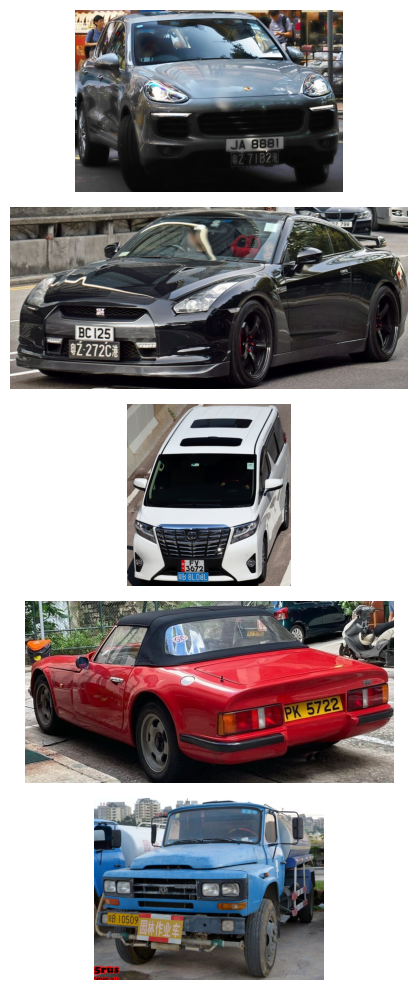

In [6]:
image_paths = Path(f"../{cfg['data']['images_path']}").rglob(f"*.jpg")
n = 5
fig, axes = plt.subplots(n, 1, figsize=(8, 2 * n))

for i, path in enumerate(image_paths):
    print(path)
    if i >= n:
        break
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    axes[i].imshow(image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

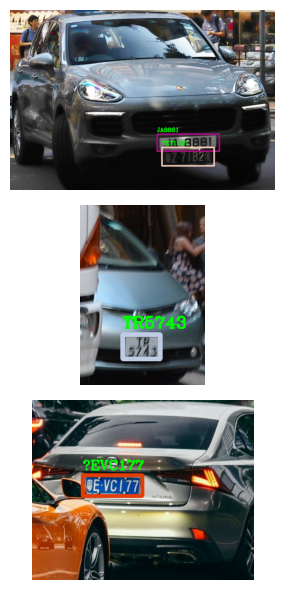

In [7]:
import numpy as np


image_paths = Path(f"../{cfg['data']['images_path']}").rglob(f"train/*.jpg")
annotations_path = Path(f"../{cfg['data']['annotations_path']}")

with open(annotations_path, "r", encoding="utf-8") as f:
    annotations = []
    f.readline()
    for ann in f.readlines():
        row = ann.split(",")
        annotations.append(
            [row[0], int(row[1]), int(row[2]), int(row[3]), int(row[4]), row[5].strip()]
        )
    
n = 3
fig, axes = plt.subplots(n, 1, figsize=(8, 2 * n))

for i, path in enumerate(image_paths):
    if i >= n:
        break
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_id = f"{path.parent.name}/{path.name}"
    image_boxes = [annotation for annotation in annotations if annotation[0] == image_id]
    
    for box in image_boxes:
        x1 = box[1]
        y1 = box[2]
        x2 = box[3]
        y2 = box[4]

        color = tuple(map(int, np.random.randint(0, 255, 3)))
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 5)
        cv2.putText(image,'%s'%(box[5]), (x1, y1-10),cv2.FONT_HERSHEY_COMPLEX,0.8,(0,255,0),2)
    axes[i].imshow(image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

План подготовки датасета:
1) Подготовить структуру
2) Составить соответствие навзание изображения - bbox в yolo-формате
3) Разделить трейн на трейн и валидацию
4) Сохранить в структуру
5) Создать конфиг

In [ ]:
import shutil
import yaml
import random
import os
from pathlib import Path


def create_dataset_template(path_to_create_dataset_template):
  """
  Создаёт шаблон структуры для хранения датасета с папками для тренировочных и валидационных изображений и меток.

  :param path_to_create_dataset_template: путь, по которому будет создана структура папок для датасета
  :return: кортеж с абсолютными путями к созданным папкам:
           - absolute_path_to_dataset: путь к основной папке датасета;
           - absolute_path_to_train_images: путь к папке с тренировочными изображениями;
           - absolute_path_to_train_labels: путь к папк е с тренировочными метками;
           - absolute_path_to_val_images: путь к папке с валидационными изображениями;
           - absolute_path_to_val_labels: путь к папке с валидационными метками
  """
  Path(path_to_create_dataset_template).mkdir(exist_ok=True)
  Path(path_to_create_dataset_template + "/images").mkdir(exist_ok=True)
  Path(path_to_create_dataset_template + "/labels").mkdir(exist_ok=True)
  
  split_paths = [os.path.join(path_to_create_dataset_template, pth) for pth in ['images/train', 'images/val', 'labels/train', 'labels/val']]
  for pth in split_paths:
    Path(pth).mkdir(exist_ok=True)
  
  absolute_path_to_dataset = Path(path_to_create_dataset_template).absolute()
  absolute_path_to_train_images = Path(split_paths[0]).absolute()
  absolute_path_to_val_images = Path(split_paths[1]).absolute()
  absolute_path_to_train_labels = Path(split_paths[2]).absolute()
  absolute_path_to_val_labels = Path(split_paths[3]).absolute()
  return absolute_path_to_dataset, absolute_path_to_train_images, absolute_path_to_train_labels, absolute_path_to_val_images, absolute_path_to_val_labels


def pascal_voc_to_yolo_boxes(image_path, bbox):
  """
  Конвертирует bbox-ы из формата Pascal VOC в формат YOLO.

  :param image_path: путь к изображению, для которого предназначен bbox
  :param bbox: bbox в формате Pascal VOC, содержащий координаты (xmin, ymin, xmax, ymax)
  :return yolo_bbox: bbox в формате YOLO, содержащий нормализованные координаты центра рамки и её размеры: [x_center_norm, y_center_norm, width_norm, height_norm]
  """
  image = cv2.imread(image_path)
  h_img, w_img, _ = image.shape
  xmin, ymin, xmax, ymax = bbox
  h = ymax - ymin 
  w = xmax - xmin
  x_center = xmin + w / 2
  y_center = ymin + h / 2

  x_center_norm = x_center / w_img
  y_center_norm =  y_center / h_img
  width_norm = w / w_img
  height_norm = h / h_img
  yolo_bbox = [x_center_norm, y_center_norm, width_norm, height_norm]

  return yolo_bbox


def train_val_split(image_paths , validation_percentage):
    """
    Разделяет список путей к изображениям на обучающую и валидационную выборки.

    :param image_paths: список путей к изображениям
    :param validation_percentage: процент данных, выделяемый для валидационной выборки (значение от 0 до 1)
    :return: кортеж, содержащий:
            - training_paths: список путей к изображениям, используемым для обучения;
            - validation_paths: список путей к изображениям, используемым для валидации
    """
    random.shuffle(image_paths)
    split_idx = int(len(image_paths) * (1 - validation_percentage))
    training_paths = image_paths[:split_idx]
    validation_paths = image_paths[split_idx:]
    return training_paths, validation_paths


def prepare_dataset(input_paths, path_to_save_images, path_to_save_labels, image_name_to_boxes):
  """
  Подготавливает датасет, копируя изображения и создавая YOLO-аннотации из bbox-ов в формате Pascal VOC.

  :param input_paths: список путей к изображениям, которые нужно обработать
  :param path_to_save_images: путь, куда будут сохранены копии изображений
  :param path_to_save_labels: путь, куда будут сохранены аннотации в формате YOLO
  :param image_name_to_boxes: словарь, сопоставляющий имя изображения и соответствующие рамки в формате Pascal VOC
  """
  for image_path in input_paths:
    # copy image_path to path_to_save_images
    image_name = image_path.stem
    src = Path(image_path)
    dst = Path(f"{path_to_save_images}/{image_name}{src.suffix}")
    shutil.copy2(src, dst)
    
    pascal_voc_boxes = image_name_to_boxes[image_name]
    yolo_boxes = [pascal_voc_to_yolo_boxes(image_path, box) for box in pascal_voc_boxes]
    
    yolo_boxes = "\n".join(["0 " + " ".join(map(str, yolo_box)) for yolo_box in yolo_boxes])
    path_to_annotation = Path(path_to_save_labels, f'{image_name}.txt')
    with open(path_to_annotation, 'w') as f_out:
      f_out.write(yolo_boxes)

 
def generate_yaml_config(dataset_path, path_to_train, path_to_val, path_to_config='config.yaml'):
    """
    Генерирует YAML-конфиг для датасета, содержащий относительные пути к тренировочной и валидационной выборкам, а также карту имён классов.

    :param dataset_path: путь к основной папке датасета
    :param path_to_train: абсолютный путь к папке с тренировочными данными
    :param path_to_val: абсолютный путь к папке с валидационными данными
    :return: абсолютный путь к созданному YAML конфигурационному файлу
    """
    config = {
        'path': str(Path(dataset_path).absolute()), # абсолютный путь к датасету
        'train': str(Path(path_to_train).relative_to(dataset_path)), # путь к train-изображениям относительно dataset_path
        'val':  str(Path(path_to_val).relative_to(dataset_path)), # # путь к val-изображениям относительно dataset_path
        'names': {
            '0': 'plate'
            },

    }
    path_to_config = Path(f"../{path_to_config}")
    with open(path_to_config, 'w') as file:
        yaml.dump(config, file)
    absolute_path_to_config = path_to_config.resolve()
    return absolute_path_to_config

  
def make_yolo_dataset(cfg) -> str:
    """Полностью создает датасет для обучения yolo

    Args:
        cfg (_dict_): словарь с базовым конфигом

    Returns:
        str: абсолютный путь к конфигу датасета для обучения yolo
    """
    # Создать структуру
    path_to_dataset, path_to_train_images, path_to_train_labels, path_to_val_images, path_to_val_labels = create_dataset_template(f"../{cfg['data']['yolo_dataset_path']}")
    
    # Получить пути к изображениям (train)
    image_paths = list(Path(f"../{cfg['data']['images_path']}").rglob(f"train/*.jpg"))
    annotations_path = Path(f"../{cfg['data']['annotations_path']}")
    
    # Получить аннтоции, положить в словарь 'название': pascal_voc bbox
    image_name_to_boxes = dict()
    with open(annotations_path, "r", encoding="utf-8") as f:
        f.readline()
        for ann in f.readlines():
            row = ann.split(",")
            image_name = Path(row[0]).stem
            bbox = (int(row[1]), int(row[2]), int(row[3]), int(row[4]))
            
            if image_name not in image_name_to_boxes:
                image_name_to_boxes[image_name] = []
            image_name_to_boxes[image_name].append(bbox)
            
    # Разделить на train/val
    train_image_paths, val_image_paths = train_val_split(image_paths, 0.15)
    
    # prepare_dataset для train и val
    prepare_dataset(train_image_paths, path_to_train_images, path_to_train_labels, image_name_to_boxes)
    prepare_dataset(val_image_paths, path_to_val_images, path_to_val_labels, image_name_to_boxes)
    
    absolute_path_to_config = generate_yaml_config(path_to_dataset, path_to_train_images, path_to_val_images, path_to_config=cfg['data']['yolo_dataset_config'])
    return absolute_path_to_config

In [5]:
from omegaconf import OmegaConf

cfg = OmegaConf.load('../config/config.yaml')
#make_yolo_dataset(cfg)

YOLO формат
(x_center_normalize, y_center_normalize, width_normalize, height_normalize)
bbox:
 [0.7680412371134021, 0.8854489164086687, 0.07731958762886598, 0.043343653250773995]
(646, 776, 3)


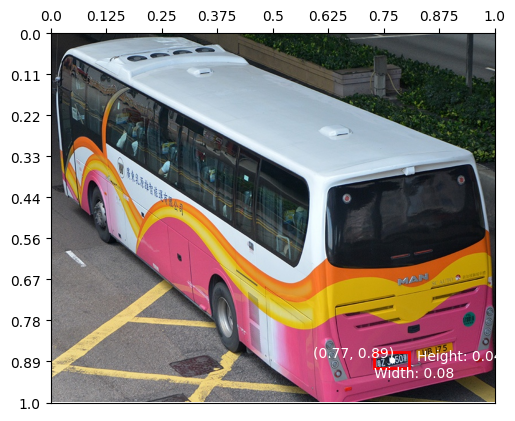

In [11]:
def visualize_yolo_bbox(image, bbox):
    print('YOLO формат\n(x_center_normalize, y_center_normalize, width_normalize, height_normalize)')
    print('bbox:\n', bbox)
    # Переводим изображение из тензора в numpy-массив
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # Получаем размеры изображения
    h, w, _ = image.shape
    print(image.shape)
    # Декодируем координаты YOLO
    x_center, y_center, width, height = bbox

    # Преобразуем нормализованные координаты в пиксели
    x_center_pix = x_center * w
    y_center_pix = y_center * h
    width_pix = width * w
    height_pix = height * h

    # Вычисляем верхний левый угол и нижний правый угол
    xmin = int(x_center_pix - width_pix / 2)
    ymin = int(y_center_pix - height_pix / 2)
    xmax = int(x_center_pix + width_pix / 2)
    ymax = int(y_center_pix + height_pix / 2)

    # # Рисуем прямоугольник на изображении
    # plt.imshow(image)
    # plt.axis('off')  # Отключаем оси
      # Рисуем bbox
    rect = patches.Rectangle((xmin, ymin), width_pix, height_pix, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)


    # Визуализируем центр
    ax.scatter(x_center_pix, y_center_pix, color='white', s=10, marker='o')
    plt.text(x_center_pix + 5, y_center_pix, f'({round(x_center,2)}, {round(y_center,2)})', fontsize=10, color='white', ha='right', va='bottom')

    # # Добавляем текст для высоты и ширины
    plt.text(x_center_pix - 30, ymax + 15, f"Width: {width:.2f}", color='white', fontsize=10)
    plt.text(xmax + 15, y_center_pix, f"Height: {height:.2f}", color='white', fontsize=10)

    # Устанавливаем относительные оси от 0 до 1
    ax.set_xticks(np.linspace(0, w, num=9))  # 6 меток по оси X
    ax.set_yticks(np.linspace(0, h, num=10))  # 6 меток по оси Y

    # Настраиваем метки для относительных значений
    ax.set_xticklabels(np.linspace(0, 1, num=9), rotation=0)
    ax.set_yticklabels(np.round(np.linspace(0, 1, num=10), 2))  # Переворот для правильного отображения Y
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    # Показываем изображение
    plt.show()

# Пример использования
image = cv2.imread("../data/processed/detector/images/train/000000_0.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

with open("../data/processed/detector/labels/train/000000_0.txt", "r") as f:
    yolo_box = list(map(float, f.readline().split()[1:]))
visualize_yolo_bbox(image, yolo_box)
